In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
import rebound
sys.path.append('../spock/')

from features import find_strongest_MMR_width, get_pairs, hillFac, massFacEccentricityBoth, massFacLargestMass, massFac
try:
    plt.style.use('paper')
except:
    pass
%matplotlib inline

Load the models and data

In [3]:
# #load datapath for clean training data that is generated
datapath = '../training_data/dataset/resonant/'
# mis_data = pd.read_csv(datapath + 'possible_misclassified.csv', index_col=0)
# mis_data = pd.read_csv(datapath + 'misclassified_pred_stable.csv', index_col=0)
# mis_data = pd.read_csv(datapath + '7-11-25-97percent.csv', index_col=0)
# data = pd.read_csv(datapath + '7-30-25-FINALx2.csv')
data = pd.read_csv(datapath + '11-20-25data.csv')
# #remove junk columns
# mis_data = mis_data.drop(columns=['Unnamed: 0','Unnamed: 0.1'])

In [4]:
Stable_enough = (data[data['shortIntegrationStable']==True])



We want to visuals the phi angles to see if systems are in resonance. We can look further into unique systems to determine any edge cases. 

In [4]:
def plot_resonant_angles(system, pair = None):
    """
    Computes and plots all q+1 resonant angles phi for a a:b MMR of order q=k.
    """

    # load the simulation for the given system
    sim = rebound.Simulation(datapath + "clean_initial_conditions.bin", snapshot=system)

    # get the relevant pair
    trio = [1, 2, 3]
    # pair_info = get_pairs(sim, trio)
    # _, i1, i2 = pair_info[0]  # i1 = inner, i2 = outer

    if pair is None:  
        pair_info = get_pairs(sim, trio)
        _, i1, i2 = pair_info[0]
    else:
        i1, i2 = pair 

    # strongest MMR
    j, k, dRatio = find_strongest_MMR_width(sim, i1, i2)
    q = k
    a = j - q
    b = j

    # store the phi time series for each (A, B) pair in a dictionary
    tmax=500
    Nsteps=1000
    times = np.linspace(0, tmax, Nsteps)
    phi_series = {}
    phi_series["pomega12"] = []
    
    for A in range(q + 1):
        B = q - A
        label = f"A={A}, B={B}"
        phi_series[label] = []

    for t in times:
        sim.integrate(t)
        ps = sim.particles

        lambda1 = ps[i1].l # inner
        lambda2 = ps[i2].l # outer
        pomega1 = ps[i1].pomega # inner
        pomega2 = ps[i2].pomega # outer

        # standard phis
        for A in range(q + 1):
            B = q - A
            label = f"A={A}, B={B}"
            phi = b * lambda2 - a * lambda1 - A * pomega1 - B * pomega2
            phi = np.mod(phi, 2 * np.pi)
            phi_series[label].append(phi)

        # calculate relative pomega
        ex = ps[i1].e * np.cos(ps[i1].pomega) - ps[i2].e * np.cos(ps[i2].pomega)
        ey = ps[i1].e * np.sin(ps[i1].pomega) - ps[i2].e * np.sin(ps[i2].pomega)
        pomega12 = np.arctan2(ey, ex) 


        # relative phi
        phi_rel = b * lambda2 - a * lambda1 - k * pomega12
        phi_rel = np.mod(phi_rel, 2 * np.pi)
        phi_series["pomega12"].append(phi_rel)

    # one plot with all phis
    plt.figure(figsize=(8, 4))
    for label in phi_series:
        plt.plot(times, phi_series[label], label=label)
    plt.xlabel("time")
    plt.ylabel(r"$\phi(t)$ (rad)")
    plt.xlim(0,500) # change if needed
    plt.title(f"Libration of Phi for {a}:{b} (system {system})")
    plt.grid(True)
    plt.legend()
    plt.show()
    

    # make phi graphs for other pair of planets 
    # print (what is 2brfillmax, which two planets it corresponds to)
    # title should print biggest 2br,planers 1,2, here are three strongest, what is dratio
    # plot phi plot and e we have then do the same for other pair 
    # list top three mmrwidth to make sure function is working (print statemnt in mmrstrength)



    # for individual plots of each phi
    # for label, phi_vals in phi_series.items():
    #     plt.figure(figsize=(8, 4))
    #     plt.plot(times, phi_vals, label=label)
    #     plt.xlabel("time")
    #     plt.ylabel(r"$\phi(t)$ (rad)")
    #     plt.title(f"Libration of Phi {label} for {a}:{b} (system {system})")
    #     plt.grid(True)
    #     plt.legend()
    #     plt.show()   
    
    


In [5]:
def plot_resonant_angles_other_pair(system):
    sim = rebound.Simulation(datapath + "clean_initial_conditions.bin", snapshot=system)
    trio = [1, 2, 3]
    pair_info = get_pairs(sim, trio)
    _, i1, i2 = pair_info[0]

    all_pairs = [(1, 2), (2, 3)]
    if (i1, i2) in all_pairs:
        all_pairs.remove((i1, i2))
    elif (i2, i1) in all_pairs:
        all_pairs.remove((i2, i1))
    other_inner, other_outer = all_pairs[0]

    print(f"^^^^ get_pairs for selected planets {i1}:{i2}.")
    print(f"plotting phi for the other pair: planets {other_inner}:{other_outer}.")

    plot_resonant_angles(system, pair=(other_inner, other_outer))


In [6]:
# bins = [(0.0, 0.2), (0.2, 0.4), (0.4, 0.6), (0.6, 0.8), (0.8, 1.0)]

# def get_systems_in_range(data, low, high, n=5):
#     mask = (data["conjunctionMagMax"] >= low) & (data["conjunctionMagMax"] < high)
#     subset = data.loc[mask]
#     if subset.empty:
#         return []
#     sample = subset.sample(min(len(subset), n), random_state=42)
#     return [(idx, row["conjunctionMagMax"]) for idx, row in sample.iterrows()]

# systems_by_bin = {
#     f"{low:.1f}-{high:.1f}": get_systems_in_range(data, low, high)
#     for (low, high) in bins
# }

# for label, systems in systems_by_bin.items():
#     print(f"\n-- Plotting systems with conjunctionMagMax in {label} --")
#     if not systems:
#         print("  (no systems)")
#         continue

#     for system_idx, mag in systems:
#         print(f"  Plotting system {system_idx} (conjunctionMagMax = {mag:.3f})")
#         try:
#             plot_resonant_angles(system_idx)
#             plot_resonant_angles_other_pair(system_idx)
#         except Exception as e:
#             print(f"  Skipping system {system_idx}: {e}")


Check if eccentricty goes to 0 for unique phi angles. When an orbit becomes circular (e=0), the pomega in phi becomes undefined (since no direction to peri-center.) 

In [7]:
def plot_eccentricty(system):
    """
    Plots e1(t), e2(t), and relative eccentricity |e1 - e2| over time.
    """
    # load the simulation for the given system
    sim = rebound.Simulation(datapath + "clean_initial_conditions.bin", snapshot=system)

    # get the relevant pair
    # the first returned element pair_info[0] has indices for 
    # pair with the largest 2BRFillfac
    trio = [1, 2, 3]
    pair_info = get_pairs(sim, trio)
    _, i1, i2 = pair_info[0]  # i1 = inner, i2 = outer

    # i1, i2 = 1, 2

    tmax=500
    Nsteps=1000
    times = np.linspace(0, tmax, Nsteps)

    e1_vals = []
    e2_vals = []
    rel_e_vals = []

    for t in times:
        sim.integrate(t)
        ps = sim.particles

        e1 = ps[i1].e
        e2 = ps[i2].e

        # Complex eccentricity vectors
        evec1 = e1 * np.exp(1j * ps[i1].pomega)
        evec2 = e2 * np.exp(1j * ps[i2].pomega)

        rel_e = np.abs(evec2 - evec1)

        e1_vals.append(e1)
        e2_vals.append(e2)
        rel_e_vals.append(rel_e)


    plt.figure(figsize=(8, 4))
    color_map = {1: 'blue', 2: 'orange', 3: 'green'}
    plt.plot(times, e1_vals, label=f"e1 = {i1}", color=color_map.get(i1, 'gray'))
    plt.plot(times, e2_vals, label=f"e2 = {i2}", color=color_map.get(i2, 'gray'))
    plt.plot(times, rel_e_vals, label=f"|e2 - e1|", color='black')
    plt.xlabel("time")
    plt.ylabel("eccentricity")
    plt.xlim(0,500)
    plt.title(f"Eccentricities over Time (system {system})")
    plt.grid(True)
    plt.legend()
    plt.show()


In [8]:
def plot_eccentricty_all(system):
    """
    Plots e1(t), e2(t), and e3(t) over time.
    """
    # load the simulation for the given system
    sim = rebound.Simulation(datapath + "clean_initial_conditions.bin", snapshot=system)

    tmax = 500
    Nsteps = 1000
    times = np.linspace(0, tmax, Nsteps)

    e_vals = {1: [], 2: [], 3: []}

    for t in times:
        sim.integrate(t)
        ps = sim.particles

        for i in [1, 2, 3]:
            e_vals[i].append(ps[i].e)

    plt.figure(figsize=(8, 4))
    color_map = {1: 'blue', 2: 'orange', 3: 'green'}
    for i in [1, 2, 3]:
        plt.plot(times, e_vals[i], label=f"e{i}", color=color_map.get(i, 'gray'))
    plt.xlabel("time")
    plt.ylabel("eccentricity")
    plt.xlim(0,500)
    plt.title(f"ALL Eccentricities over Time (system {system})")
    plt.grid(True)
    plt.legend()
    plt.show()

In [9]:
def plot_hillFac(system):
    """
    Plots Hill stability factor over time for a pair of planets in a rebound simulation.
    """
    # load the simulation for the given system
    sim = rebound.Simulation(datapath + "clean_initial_conditions.bin", snapshot=system)

    # get the relevant pair
    # the first returned element pair_info[0] has indices for 
    # pair with the largest 2BRFillfac
    trio = [1, 2, 3]
    pair_info = get_pairs(sim, trio)
    _, i1, i2 = pair_info[0]  # i1 = inner, i2 = outer


    hillFac_values = []
    tmax=500
    Nsteps=1000
    times = np.linspace(0, tmax, Nsteps)
    
    for t in times:
        sim.integrate(t)
        hf = hillFac(sim, i1, i2)  
        hillFac_values.append(hf)

    print(f"hillfac = {hf}")

    # Plot results
    # plt.figure(figsize=(8,5))
    # plt.plot(times, hillFac_values, marker='o')
    # plt.xlabel('Time')
    # plt.ylabel('Hill Stability Factor')
    # plt.title(f'Hill Stability Factor for planets {i1} and {i2}')
    # plt.grid(True)
    # plt.axhline(1.0, color='r', linestyle='--', label='Stability Threshold (hillFac=1)')
    # plt.legend()
    # # plt.show()


In [10]:
# bins = [(0.0, 0.2), (0.2, 0.4), (0.4, 0.6), (0.6, 0.8), (0.8, 1.0)]

# def get_systems_in_range(data, low, high):
#     mask = (data["conjunctionMagMax"] >= low) & (data["conjunctionMagMax"] < high)
#     return data.loc[mask]

# systems_by_bin = {
#     f"{low:.1f}-{high:.1f}": get_systems_in_range(data, low, high)
#     for (low, high) in bins
# }

# for label, systems in systems_by_bin.items():
#     print(f"\n{label}:")
#     if systems.empty:
#         print("  (no systems)")
#     else:
#         for idx, row in systems.iterrows():
#             print(f"  System {idx}: conjunctionMagMax = {row['conjunctionMagMax']:.3f}")


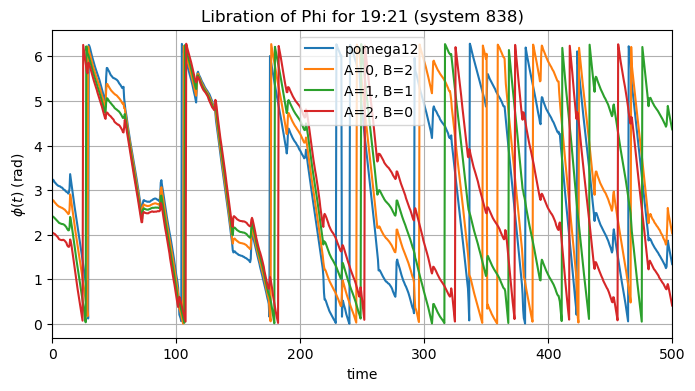

^^^^ get_pairs for selected planets 2:3.
plotting phi for the other pair: planets 1:2.


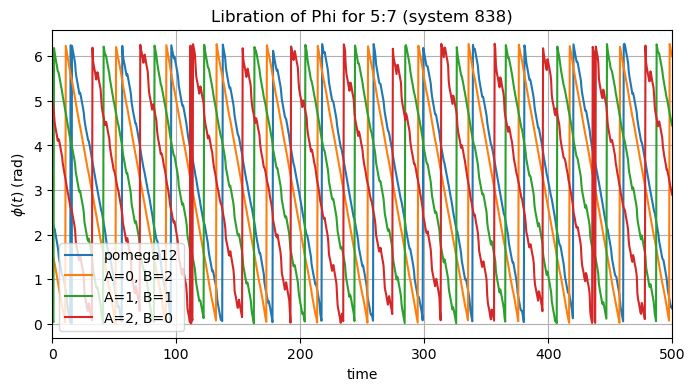

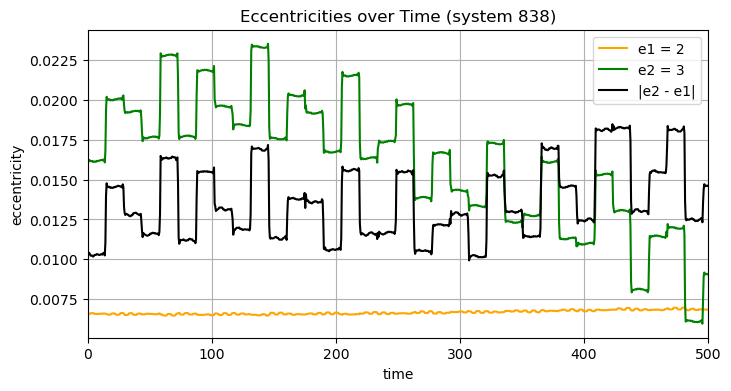

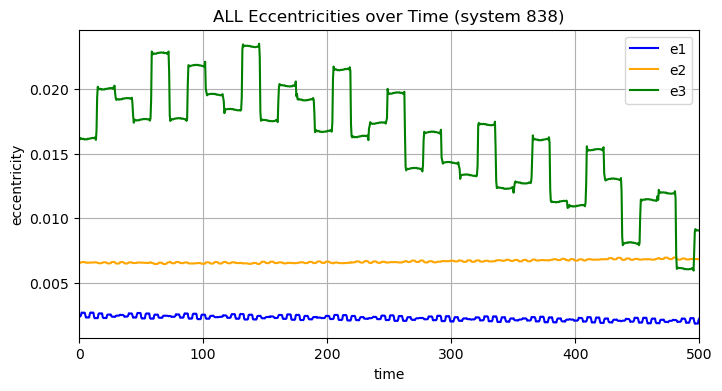

hillfac = 1.0720182160214773


In [14]:
system = 838
plot_resonant_angles(system)
plot_resonant_angles_other_pair(system)
plot_eccentricty(system)
plot_eccentricty_all(system)
plot_hillFac(system)

massFac: 15.224
lowest std: 0.395
lowest std NORM: 0.395
largest mass: 0.395
min e : 2.701534e-05


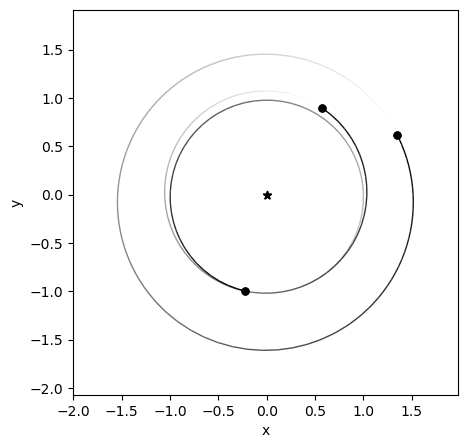

In [12]:
system = 680
sim = rebound.Simulation(datapath + "clean_initial_conditions.bin", snapshot=system)
massFac = mis_data.loc[system, 'massFac']
lowestSTD = mis_data.loc[system, 'mass_fac_lowest_std']
lowestSTD_NORM = mis_data.loc[system, 'mass_fac_lowest_norm_std']
largeMass = mis_data.loc[system, 'massFacLargeMass']

minE = mis_data.loc[system, 'min_e_std']

print(f"massFac: {massFac:.3f}")
print(f"lowest std: {lowestSTD:.3f}")
print(f"lowest std NORM: {lowestSTD_NORM:.3f}")
print(f"largest mass: {largeMass:.3f}")
print(f"min e : {minE:.6e}")
fig = rebound.OrbitPlot(sim)
plt.show()


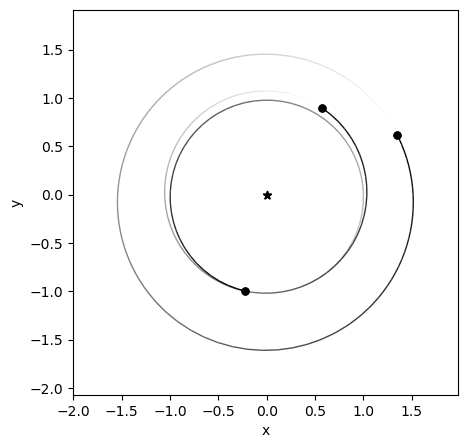

planet 1 mass: 5.525e-06
planet 2 mass: 1.538e-06
planet 3 mass: 1.789e-05


In [13]:
sim = rebound.Simulation(datapath + "clean_initial_conditions.bin", snapshot=system)
fig = rebound.OrbitPlot(sim)
plt.show()

trio = [1, 2, 3]
ps = sim.particles
for i in trio:
    print(f"planet {i} mass: {ps[i].m:.3e}")

In [1]:
import rebound
from spock.features import hillFac

sim = rebound.Simulation()
sim.add(m=1)
sim.add(m=1e-5, a=1, primary=sim.particles[0])
sim.add(m=1e-5, a=1.065, primary=sim.particles[0], f=3.14)
ps = sim.particles
# fig = rebound.OrbitPlot(sim)
# plt.show()
orbs = sim.orbits(primary=sim.particles[0])
delta = (orbs[1].a - orbs[0].a)/orbs[0].a
print((ps[2].a - ps[1].a)/ps[1].a)
print(delta)
hillFac(sim, 1,  2)


0.06503133171982746
0.06500000000000018


0.9725109022812414

In [2]:
ps = sim.particles
orbs = sim.orbits(primary=sim.particles[0])
delta = (orbs[1].a - orbs[0].a)/orbs[0].a
delta_crit = (2.4*(((ps[1].m+ps[2].m)**(1/3))/(ps[0].m)**(1/3)))
test = delta/delta_crit
test

0.9977585308817739

a2=1.05234, param = 1.00068916 ✅
a2=1.05838, param = 1.00078508 ✅
a2=1.06140, param = 1.00083884 ✅
a2=1.06442, param = 1.00089624 ✅
a2=1.06744, param = 1.00095717 ✅
a2=1.07046, param = 1.00102150 ✅
a2=1.07348, param = 1.00108914 ✅
a2=1.07651, param = 1.00116000 ✅
a2=1.07953, param = 1.00123402 ✅
a2=1.08255, param = 1.00131111 ✅
a2=1.08557, param = 1.00139122 ✅
a2=1.08859, param = 1.00147430 ✅
a2=1.09161, param = 1.00156028 ✅
a2=1.09463, param = 1.00164914 ✅
a2=1.09765, param = 1.00174081 ✅
a2=1.10067, param = 1.00183526 ✅
a2=1.10369, param = 1.00193245 ✅
a2=1.10671, param = 1.00203235 ✅
a2=1.10973, param = 1.00213492 ✅
a2=1.11275, param = 1.00224012 ✅
a2=1.11577, param = 1.00234794 ✅
a2=1.11879, param = 1.00245832 ✅
a2=1.12181, param = 1.00257126 ✅
a2=1.12483, param = 1.00268672 ✅
a2=1.12785, param = 1.00280466 ✅
a2=1.13087, param = 1.00292508 ✅
a2=1.13389, param = 1.00304794 ✅
a2=1.13691, param = 1.00317321 ✅
a2=1.13993, param = 1.00330088 ✅
a2=1.14295, param = 1.00343092 ✅
a2=1.14597

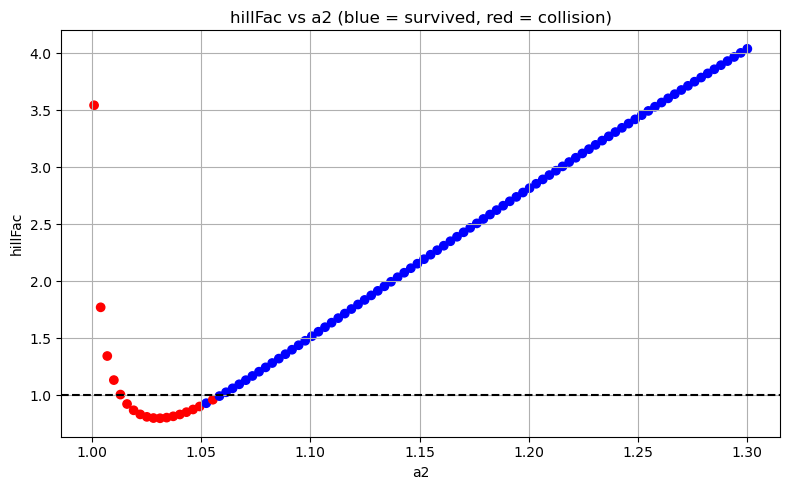

In [2]:
import rebound
import numpy as np
from spock.features import hillFac
import matplotlib.pyplot as plt

a2_values = np.linspace(1.001, 1.3, 100)

results = []

for a2 in a2_values:
    m0 = 1
    m1 = 1e-5
    m2 = 1e-5
    a1 = 1
    r = min((a2-a1)/10, (m1/m0)**(1/3)) # make sure r is much smaller than the initial separation

    sim = rebound.Simulation()
    sim.add(m=m0)
    sim.add(m=m1, a=a1, r = r, primary=sim.particles[0])
    sim.add(m=m2, a=a2, r=r, primary=sim.particles[0])

    sim.collision = "direct"
    collided = []

    try:
        sim.integrate(1e5) 
    except rebound.Collision:
        collided = True

    hf = hillFac(sim, 1, 2)

    if not collided:
        ps = sim.particles
        M = m0 + m1 + m2
        M_prod = m1 * m2 + m1 * m0 + m2 * m0
        G = sim.G

        c_vec = np.zeros(3)
        KE = 0
        for j in [0, 1, 2]:
            r_j = np.array([ps[j].x, ps[j].y, ps[j].z])
            v_j = np.array([ps[j].vx, ps[j].vy, ps[j].vz])
            c_vec += ps[j].m * np.cross(r_j, v_j)
            v = np.linalg.norm(v_j)
            KE += 0.5 * ps[j].m * v**2
        c = np.linalg.norm(c_vec)

        U = 0
        for j1, j2 in [[0, 1], [0, 2], [1, 2]]:
            r_a = np.array([ps[j1].x, ps[j1].y, ps[j1].z])
            r_b = np.array([ps[j2].x, ps[j2].y, ps[j2].z])
            r = np.linalg.norm(r_a - r_b)
            U += - (G * ps[j1].m * ps[j2].m) / r
        h = KE + U

        param = - ((2 * M) / (G**2 * M_prod**3)) * c**2 * h
        print(f"a2={a2}, param = {param} {'✅' if param > 1 else '❌'}")


    results.append((a2, hf, not collided))


a2_list = [item[0] for item in results]
hf_list = [item[1] for item in results]
survived_list = [item[2] for item in results]

a2_list = np.array(a2_list)
hf_list = np.array(hf_list)
survived_list = np.array(survived_list)

colors = ['blue' if survived else 'red' for survived in survived_list]

plt.figure(figsize=(8, 5))
plt.scatter(a2_list, hf_list, c=colors)
plt.axhline(y=1, color='black', linestyle='--', linewidth=1.5, label='1 cutoff?')
plt.xlabel("a2")
plt.ylabel("hillFac")
plt.title("hillFac vs a2 (blue = survived, red = collision)")
plt.grid(True)


plt.tight_layout()
plt.show()


In [3]:
(125000624981250.16-124999999999999.97)/125000624981250.16

4.999825003124952e-06

In [40]:
ps = sim.particles
RH = 2.4*ps[1].a*((ps[1].m+ps[2].m)/ps[0].m)**(1/3)
Delta = (ps[2].a-ps[1].a)/RH
Delta

0.9982394768932333

In [ ]:
#q=2
64769
91701

# interesting
51878
59044
75282

# systems with same pattern 
11519
81783
90858
93127
98955
19116
2163


Check the 2BRFillFac for systems to explain their instability.

In [31]:
twoBR = (mis_data['2BRfillMax']>1).sum()
twoBR

0

Check the threeBRFillFac for systems to explain their instability.

In [38]:
threebr = (mis_data['threeBRfillfac']<1).sum()
threebr

162

In [47]:
threeBR = mis_data[['threeBRfillfac']]
isnull = mis_data['threeBRfillfac'].isnull().sum()
isnull


9

Below is used for testing certain systems (checking tseries) that aren't behaving as we'd expect:

In [6]:
sim = rebound.Simulation(datapath + "clean_initial_conditions.bin", snapshot=129)
hf = hillFac(sim, 2, 3)
print(hf)

2.2262616477159045


/home/miniconda3/envs/sorobertson/lib/python3.12/site-packages/rebound/simulation.py:153: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed.
  warnings.warn(message, RuntimeWarning)


In [10]:
from spock.simsetup import init_sim_parameters
from spock.tseries_feature_functions import get_tseries
sim = rebound.Simulation(datapath + "clean_initial_conditions.bin", snapshot=183)
init_sim_parameters(sim)
triotseries, stable = get_tseries(sim, (1e4, 80, [[1,2,3]]))
stable

True

In [11]:
triotseries

[array([[0.00000000e+00, 6.39249959e-02, 5.55132348e-02, 8.43160928e-01,
         9.55847312e-02, 1.79539477e-02, 8.28239761e-02, 0.00000000e+00],
        [1.26619793e+02, 6.37022122e-02, 5.52117695e-02, 4.66172556e+00,
         9.52938677e-02, 1.80005744e-02, 8.22435184e-02, 1.72807385e+00],
        [2.53200336e+02, 6.26398223e-02, 5.47322594e-02, 1.17694922e+00,
         9.48062243e-02, 1.80186750e-02, 8.25865959e-02, 1.82978922e+00],
        [3.79780879e+02, 6.01627019e-02, 5.43385002e-02, 1.37298676e+00,
         9.44478030e-02, 1.80138795e-02, 8.25554696e-02, 1.86487179e+00],
        [5.06361422e+02, 5.73653058e-02, 5.42739966e-02, 4.57143282e-01,
         9.44690282e-02, 1.79811945e-02, 8.33335098e-02, 1.89071962e+00],
        [6.32941966e+02, 5.42783605e-02, 5.43981542e-02, 1.06535636e+00,
         9.46947347e-02, 1.79756487e-02, 8.26479666e-02, 1.90470117e+00],
        [7.59522509e+02, 5.38341170e-02, 5.48718576e-02, 4.33676094e-01,
         9.52110472e-02, 1.79625326e-02, 8.28